# 02 Exploratory Data Analysis

UCI Bank Marketing Dataset — cleaned data from `01_data_understanding_and_cleaning.ipynb`.

This notebook investigates patterns and associations between customer/campaign characteristics and term-deposit subscription. It does not encode, scale, split, engineer features, or model anything — the goal is understanding, not preparation. `duration` is analyzed but no leakage decision is made about it (notebook 03). `pdays == 999` is analyzed but the engineered `was_previously_contacted` flag is not created here (notebook 04).

## 1. Load Cleaned Dataset

Loading `data/processed/bank_marketing_cleaned.csv` — the raw file is not used here unless explicitly noted.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', None)

BLUE = '#2a78d6'
ORANGE = '#eb6834'
RED = '#e34948'
MUTED = '#898781'
GRID = '#e1e0d9'

plt.rcParams.update({
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'font.size': 10,
})

df = pd.read_csv('../data/processed/bank_marketing_cleaned.csv')
df.shape

(41176, 21)

## 2. Initial Verification

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.isnull().sum().sum(), df.duplicated().sum()

(np.int64(0), np.int64(0))

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include='object').columns if c != 'y']
numerical_cols, categorical_cols

(['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

Zero nulls, zero duplicates, and the same column structure as notebook 01's output — confirms this is the correct cleaned dataset.

## 3. Target Variable Analysis

**Q1/Q2 — What is the overall subscription rate, and how is the target distributed?**

In [11]:
target_counts = df['y'].value_counts()
target_rate = (df['y'] == 'yes').mean() * 100
print(target_counts)
print(f'Overall subscription rate: {target_rate:.2f}%')

y
no     36537
yes     4639
Name: count, dtype: int64
Overall subscription rate: 11.27%


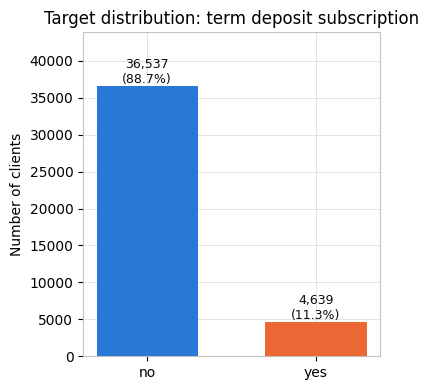

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(target_counts.index, target_counts.values, color=[BLUE, ORANGE], width=0.6)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 400, f'{v:,}\n({v / len(df) * 100:.1f}%)', ha='center', color='#0b0b0b', fontsize=9)
ax.set_ylabel('Number of clients')
ax.set_title('Target distribution: term deposit subscription')
ax.set_ylim(0, target_counts.max() * 1.2)
plt.tight_layout()
plt.show()

88.73% `no` vs 11.27% `yes` (4,640 of 41,176 clients) — confirms the class imbalance already flagged in notebook 01. Not corrected here; it's a modeling-phase decision (metric choice, resampling, class weighting).

## 4. Numerical Feature Analysis

**Q3 — What does the age distribution look like, and what do the other numeric features look like overall (before comparing against the target)?**

In [13]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


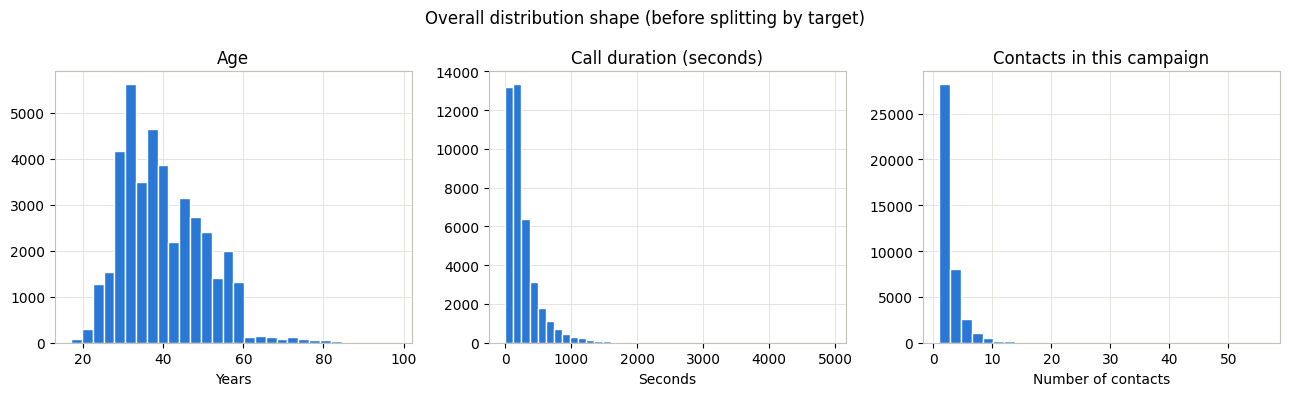

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(df['age'], bins=30, color=BLUE, edgecolor='white')
axes[0].set_title('Age')
axes[0].set_xlabel('Years')

axes[1].hist(df['duration'], bins=40, color=BLUE, edgecolor='white')
axes[1].set_title('Call duration (seconds)')
axes[1].set_xlabel('Seconds')

axes[2].hist(df['campaign'], bins=30, color=BLUE, edgecolor='white')
axes[2].set_title('Contacts in this campaign')
axes[2].set_xlabel('Number of contacts')

fig.suptitle('Overall distribution shape (before splitting by target)')
plt.tight_layout()
plt.show()

- `age` is right-skewed but broadly bell-shaped, concentrated in the 30–50 range (25th–75th percentile: 32–47), with a long tail out to 98.
- `duration` is heavily right-skewed — median 180s but a mean of 258s and a max of 4,918s (~82 minutes), so a small number of very long calls pull the distribution far to the right.
- `campaign` is also right-skewed: most clients are contacted 1–3 times (median 2), but the tail extends to 56.

`pdays` and `previous` are not shown here as histograms — both are dominated by a single value (`pdays == 999` for the large majority; `previous == 0` for 86%), so a bucketed comparison in Section 8 is more informative than a raw histogram. The economic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are macro values that repeat across many rows sharing the same time period — their per-customer shape isn't meaningful on its own, so they're addressed directly in the correlation analysis (Section 9).

## 5. Categorical Feature Analysis

Composition of the customer/campaign population, independent of the target — cardinality and category proportions. Subscription **rate** by category (the more decision-relevant view) follows in Sections 6–8.

In [15]:
df[categorical_cols].nunique().sort_values()

contact         2
default         3
housing         3
loan            3
poutcome        3
marital         4
day_of_week     5
education       8
month          10
job            12
dtype: int64

In [16]:
for col in categorical_cols:
    print(f'--- {col} ---')
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print()

--- job ---
job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.63
management        7.10
retired           4.17
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.13
unknown           0.80
Name: proportion, dtype: float64

--- marital ---
marital
married     60.52
single      28.08
divorced    11.20
unknown      0.19
Name: proportion, dtype: float64

--- education ---
education
university.degree      29.54
high.school            23.10
basic.9y               14.68
professional.course    12.73
basic.4y               10.14
basic.6y                5.56
unknown                 4.20
illiterate              0.04
Name: proportion, dtype: float64

--- default ---
default
no         79.12
unknown    20.88
yes         0.01
Name: proportion, dtype: float64

--- housing ---
housing
yes        52.39
no         45.21
unknown     2.40
Name: proportion, dtype: float64

--- loan ---
loan
no         82.

## 6. Subscription Rate Analysis

For categorical features, subscription **rate** is more informative than raw counts. Every chart below plots the observed rate per category against a dashed line marking the overall 11.27% baseline, and returns the underlying counts alongside it.

**Q4/Q5/Q6/Q7 — Do job, education, marital status, or housing/personal loans show different subscription rates? Q — do 'unknown' values behave differently from known categories?**

In [17]:
def subscription_rate_chart(col, order=None, title=None, figsize=(7, 4), rotate=45):
    summary = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean() * 100)
    counts = df.groupby(col).size()
    if order is not None:
        summary = summary.reindex(order)
        counts = counts.reindex(order)

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(summary.index.astype(str), summary.values, color=BLUE, width=0.6)
    ax.axhline(target_rate, color=MUTED, linestyle='--', linewidth=1)
    ax.text(0.98, 0.95, f'overall {target_rate:.1f}%', transform=ax.transAxes,
            ha='right', va='top', color=MUTED, fontsize=9)
    for i, v in enumerate(summary.values):
        ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=8, color='#0b0b0b')
    ax.set_ylabel('Subscription rate (%)')
    ax.set_title(title or f'Subscription rate by {col}')
    ax.set_ylim(0, summary.max() * 1.25)
    plt.xticks(rotation=rotate, ha='right' if rotate else 'center')
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'count': counts, 'subscription_rate_pct': summary.round(2)})

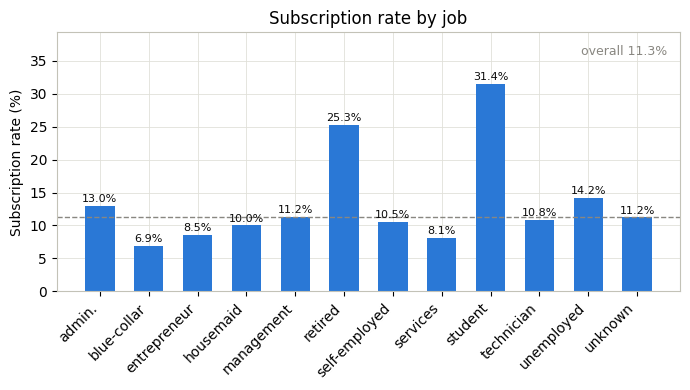

,count,subscription_rate_pct
job,,
admin.,10419,12.97
blue-collar,9253,6.90
entrepreneur,1456,8.52
housemaid,1060,10.00
management,2924,11.22
retired,1718,25.26
self-employed,1421,10.49
services,3967,8.14
student,875,31.43


In [18]:
subscription_rate_chart('job', title='Subscription rate by job')

Highest observed rates: `student` (31.4%) and `retired` (25.3%) — both well above the 11.3% baseline. Lowest: `blue-collar` (6.9%) and `services` (8.1%). `job == 'unknown'` (11.2%) sits almost exactly at the baseline — unlike `default`'s unknown category (see below), job's missing-job-title clients don't behave distinctly from the average.

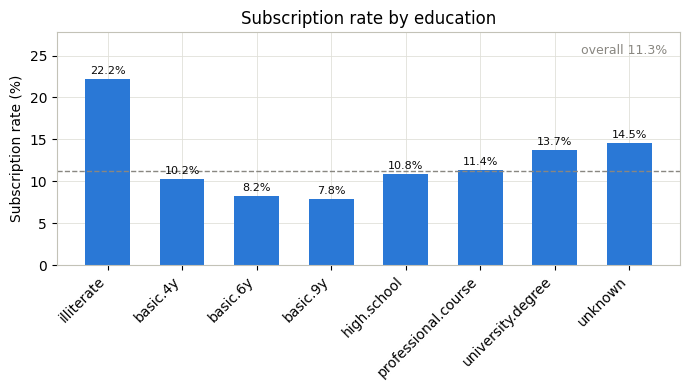

,count,subscription_rate_pct
education,,
illiterate,18,22.22
basic.4y,4176,10.25
basic.6y,2291,8.21
basic.9y,6045,7.82
high.school,9512,10.84
professional.course,5240,11.35
university.degree,12164,13.72
unknown,1730,14.51


In [19]:
subscription_rate_chart('education', order=['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown'],
                         title='Subscription rate by education', rotate=45)

No clean monotonic relationship between education level and subscription. `illiterate` shows the highest rate (22.2%) but on only 18 clients — too small to trust. Among the larger categories, `university.degree` (13.7%) is highest and `basic.9y` (7.8%) is lowest. `education == 'unknown'` (14.5%) is *above* the baseline, not below it — the opposite direction from `default`'s unknown category.

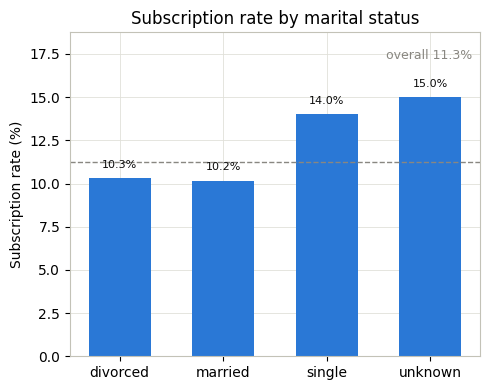

,count,subscription_rate_pct
marital,,
divorced,4611,10.32
married,24921,10.16
single,11564,14.01
unknown,80,15.00


In [20]:
subscription_rate_chart('marital', title='Subscription rate by marital status', rotate=0, figsize=(5, 4))

`single` clients show a higher rate (14.0%) than `married` (10.2%) or `divorced` (10.3%). `marital == 'unknown'` shows the highest rate (15.0%) but only 80 clients — noted, not trusted on its own.

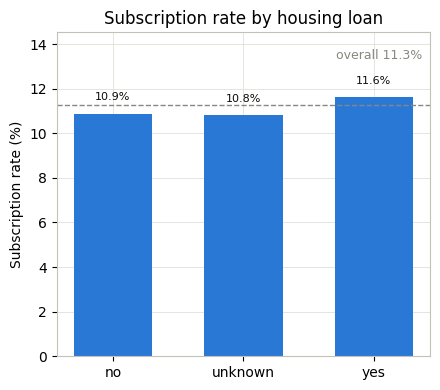

,count,subscription_rate_pct
housing,,
no,18615,10.88
unknown,990,10.81
yes,21571,11.62


In [21]:
subscription_rate_chart('housing', title='Subscription rate by housing loan', rotate=0, figsize=(4.5, 4))

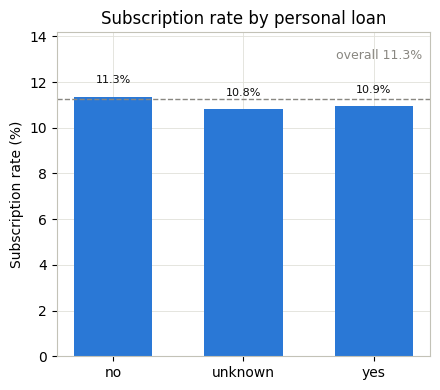

,count,subscription_rate_pct
loan,,
no,33938,11.34
unknown,990,10.81
yes,6248,10.93


In [22]:
subscription_rate_chart('loan', title='Subscription rate by personal loan', rotate=0, figsize=(4.5, 4))

Both `housing` (10.8–11.6%) and `loan` (10.8–11.3%) stay within a narrow band close to the baseline across every category, including `unknown` — neither shows a meaningful association with subscription on its own.

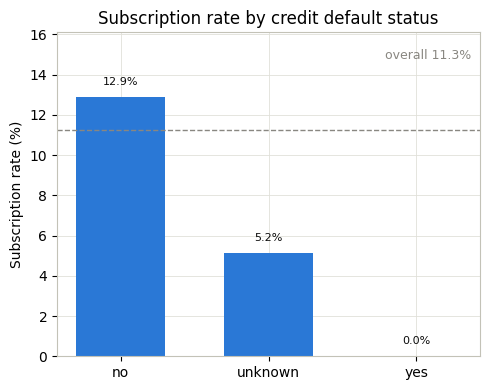

,count,subscription_rate_pct
default,,
no,32577,12.88
unknown,8596,5.15
yes,3,0.00


In [23]:
subscription_rate_chart('default', title="Subscription rate by credit default status", rotate=0, figsize=(5, 4))

This is the strongest 'unknown' finding in the dataset: `default == 'unknown'` subscribes at 5.2%, less than half the 12.9% rate of `default == 'no'` clients. `default == 'yes'` has only 3 clients (0% subscribed) and isn't reliable on its own, but the `unknown` vs `no` gap is based on large samples (8,596 vs 32,577) and is real. Unlike `job` or `housing`/`loan`, `default`'s unknown category is *not* interchangeable with 'no' — worth flagging for feature engineering.

## 7. Campaign and Contact Analysis

**Q8/Q9/Q10 — Does contact method, month, or number of campaign contacts relate to subscription?**

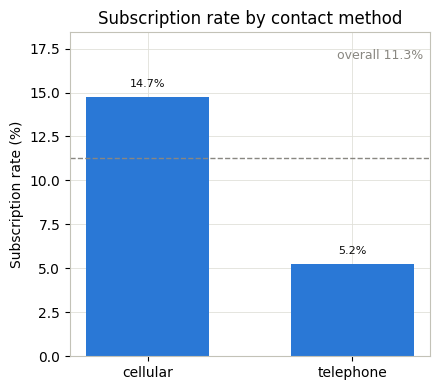

,count,subscription_rate_pct
contact,,
cellular,26135,14.74
telephone,15041,5.23


In [24]:
subscription_rate_chart('contact', title='Subscription rate by contact method', rotate=0, figsize=(4.5, 4))

`cellular` shows a markedly higher rate (14.7%) than `telephone` (5.2%) — the largest gap seen in a binary categorical feature so far.

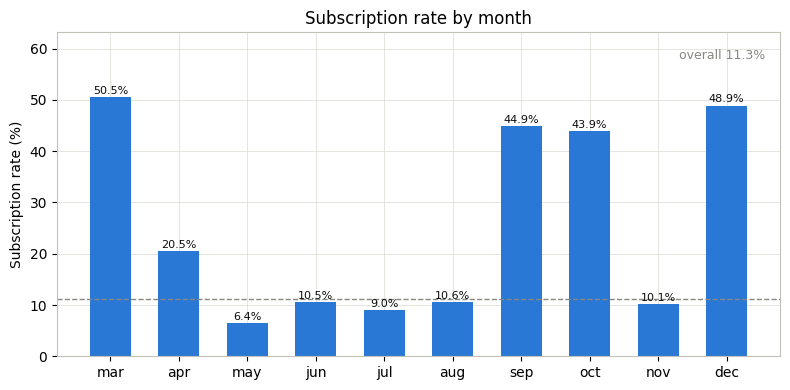

,count,subscription_rate_pct
month,,
mar,546,50.55
apr,2631,20.49
may,13767,6.44
jun,5318,10.51
jul,7169,9.04
aug,6176,10.61
sep,570,44.91
oct,717,43.93
nov,4100,10.15


In [25]:
month_order = [m for m in ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'] if m in df['month'].unique()]
subscription_rate_chart('month', order=month_order, title='Subscription rate by month', rotate=0, figsize=(8, 4))

Month shows the widest swing of any categorical feature investigated: `mar` (50.6%), `dec` (48.9%), `sep` (44.9%), and `oct` (43.9%) are far above baseline, while `may` (6.4%), `jul` (9.0%), and `nov` (10.2%) sit at or below it. The high-rate months also have far smaller sample sizes (e.g. `mar` n=546 vs `may` n=13,767) — this could reflect a genuine seasonal effect, a change in campaign strategy, or simply that this dataset spans 2008–2010 and month is entangled with *which* economic conditions (see Section 9) were in effect at the time. Flagged as a question to carry forward rather than a settled finding.

In [26]:
day_of_week_rate = df.groupby('day_of_week')['y'].apply(lambda s: (s == 'yes').mean() * 100).round(2)
day_of_week_rate.reindex(['mon', 'tue', 'wed', 'thu', 'fri'])

day_of_week
mon     9.95
tue    11.79
wed    11.67
thu    12.11
fri    10.81
Name: y, dtype: float64

`day_of_week` ranges only 9.95%–12.11% — too narrow to be a meaningful driver on its own, so no chart is warranted here.

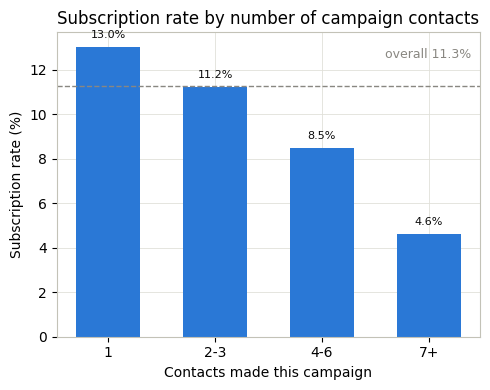

,count,subscription_rate_pct
campaign,,
1,17634,13.04
2-3,15908,11.22
4-6,5228,8.49
7+,2406,4.61


In [27]:
campaign_bucket = pd.cut(df['campaign'], bins=[0, 1, 3, 6, 60], labels=['1', '2-3', '4-6', '7+'])
rate_by_campaign = df.groupby(campaign_bucket, observed=True)['y'].apply(lambda s: (s == 'yes').mean() * 100)
count_by_campaign = df.groupby(campaign_bucket, observed=True).size()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(rate_by_campaign.index.astype(str), rate_by_campaign.values, color=BLUE, width=0.6)
ax.axhline(target_rate, color=MUTED, linestyle='--', linewidth=1)
ax.text(0.98, 0.95, f'overall {target_rate:.1f}%', transform=ax.transAxes,
        ha='right', va='top', color=MUTED, fontsize=9)
for i, v in enumerate(rate_by_campaign.values):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=8, color='#0b0b0b')
ax.set_ylabel('Subscription rate (%)')
ax.set_xlabel('Contacts made this campaign')
ax.set_title('Subscription rate by number of campaign contacts')
plt.tight_layout()
plt.show()

pd.DataFrame({'count': count_by_campaign, 'subscription_rate_pct': rate_by_campaign.round(2)})

A clear, monotonic *inverse* relationship: 13.0% for clients contacted once this campaign, falling to 11.2% (2–3 contacts), 8.5% (4–6), and 4.6% (7+). Repeated contact within a campaign is associated with a *lower*, not higher, observed subscription rate.

## 8. Previous Campaign Analysis

**Q11/Q12 — How does previous campaign outcome relate to subscription, and does prior contact history matter?**

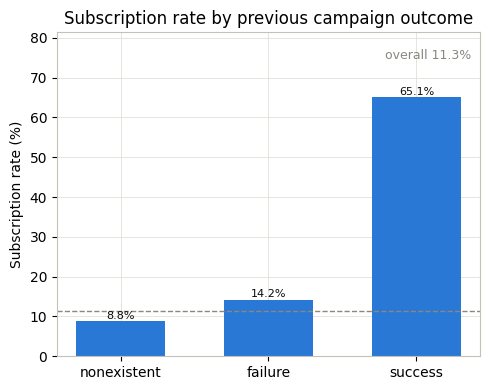

,count,subscription_rate_pct
poutcome,,
nonexistent,35551,8.83
failure,4252,14.23
success,1373,65.11


In [28]:
subscription_rate_chart('poutcome', order=['nonexistent', 'failure', 'success'], title='Subscription rate by previous campaign outcome', rotate=0, figsize=(5, 4))

The strongest association found in this notebook: clients whose previous campaign outcome was `success` subscribe at 65.1%, versus 14.2% for `failure` and 8.8% for `nonexistent` (no previous campaign). Prior positive engagement is a powerful signal.

In [29]:
previous_bucket = np.select([df['previous'] == 0, df['previous'] == 1], ['0', '1'], default='2+')
rate_by_previous = df.groupby(previous_bucket)['y'].apply(lambda s: (s == 'yes').mean() * 100).round(2)
count_by_previous = df.groupby(previous_bucket).size()
pd.DataFrame({'count': count_by_previous, 'subscription_rate_pct': rate_by_previous}).reindex(['0', '1', '2+'])

,count,subscription_rate_pct
0,35551,8.83
1,4561,21.20
2+,1064,50.00


Subscription rate rises with prior contact count: 8.8% for clients never contacted before, 21.2% for one prior contact, and 43.9% for two or more. Individual `previous` values beyond 3 (shown in raw form below) have very small sample sizes and shouldn't be over-interpreted.

In [30]:
contacted_before = df['pdays'] != 999
rate_by_contacted = df.groupby(contacted_before)['y'].apply(lambda s: (s == 'yes').mean() * 100).round(2)
count_by_contacted = df.groupby(contacted_before).size()
pd.DataFrame({'count': count_by_contacted, 'subscription_rate_pct': rate_by_contacted})

,count,subscription_rate_pct
pdays,,
False,39661,9.26
True,1515,63.83


Clients with a recorded `pdays` value (i.e. `pdays != 999`) subscribe at 63.8% versus 9.3% for those at the `999` sentinel — consistent with the `poutcome` pattern above, as expected since both describe prior contact history.

In [31]:
mismatch = df[(df['previous'] > 0) & (df['pdays'] == 999)]
print('Rows with previous > 0 but pdays == 999:', len(mismatch))
print(mismatch['poutcome'].value_counts())
print((mismatch['y'].value_counts(normalize=True) * 100).round(2))

Rows with previous > 0 but pdays == 999: 4110
poutcome
failure    4110
Name: count, dtype: int64
y
no     87.06
yes    12.94
Name: proportion, dtype: float64


**Unusual pattern worth flagging:** `pdays == 999` does not cleanly mean *"never contacted before."* 4,110 rows have `previous > 0` and `poutcome == 'failure'`, yet `pdays == 999` — every one of them. Put differently: of the 4,252 clients with a `failure` outcome, 4,110 (97%) have no recorded `pdays` value at all, while *all* 1,373 `success` clients do. This subgroup subscribes at 12.9% — distinct from both the `pdays != 999` group (63.8%) and the true never-contacted group represented by `poutcome == 'nonexistent'` (8.8%). A flag built naively as `pdays != 999` would misclassify these 4,110 previously-contacted clients as never contacted. This is carried forward to notebook 04.

## 9. Relationship and Correlation Analysis

**Q13 — Are there numerical features whose distributions differ substantially between subscribers and non-subscribers?**

In [32]:
df.groupby('y')[['age', 'campaign', 'duration']].describe().T

y                         no          yes
age      count  36537.000000  4639.000000
         mean      39.910994    40.912266
         std        9.897176    13.838838
         min       17.000000    17.000000
         25%       32.000000    31.000000
         50%       38.000000    37.000000
         75%       47.000000    50.000000
         max       95.000000    98.000000
campaign count  36537.000000  4639.000000
         mean       2.633385     2.051951
         std        2.873768     1.666353
         min        1.000000     1.000000
         25%        1.000000     1.000000
         50%        2.000000     2.000000
         75%        3.000000     2.000000
         max       56.000000    23.000000
duration count  36537.000000  4639.000000
         mean     220.868079   553.256090
         std      207.116178   401.190736
         min        0.000000    37.000000
         25%       95.000000   253.500000
         50%      164.000000   449.000000
         75%      279.000000   741.500000
         max     4918.000000  4199.000000

/var/folders/w5/3llfjkmn1xdgvr9dq_x0lzt80000gn/T/ipykernel_24754/3934037887.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['no', 'yes'], patch_artist=True,
/var/folders/w5/3llfjkmn1xdgvr9dq_x0lzt80000gn/T/ipykernel_24754/3934037887.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['no', 'yes'], patch_artist=True,
/var/folders/w5/3llfjkmn1xdgvr9dq_x0lzt80000gn/T/ipykernel_24754/3934037887.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['no', 'yes'], patch_artist=True,


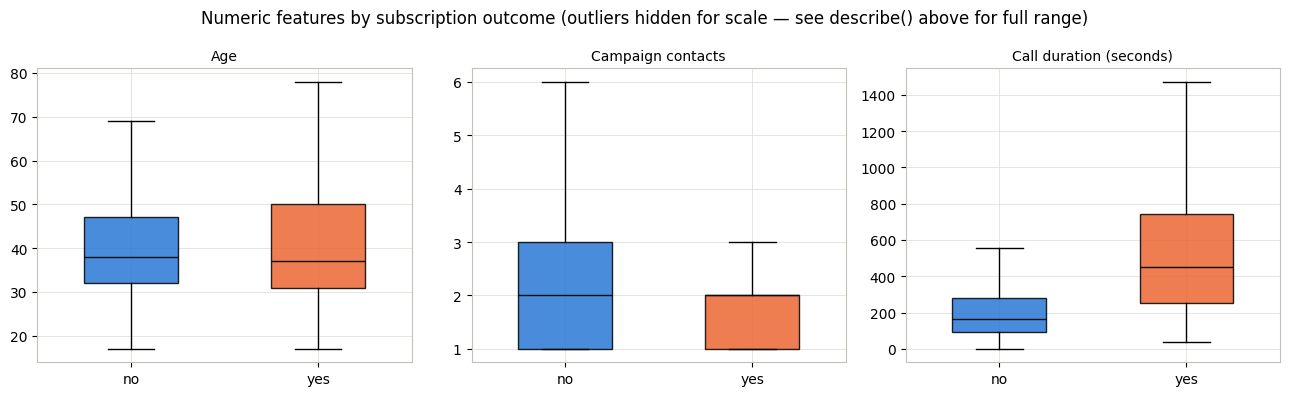

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
compare_cols = ['age', 'campaign', 'duration']
titles = ['Age', 'Campaign contacts', 'Call duration (seconds)']

for ax, col, title in zip(axes, compare_cols, titles):
    data_no = df.loc[df['y'] == 'no', col]
    data_yes = df.loc[df['y'] == 'yes', col]
    bp = ax.boxplot([data_no, data_yes], labels=['no', 'yes'], patch_artist=True,
                     widths=0.5, showfliers=False)
    for patch, color in zip(bp['boxes'], [BLUE, ORANGE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for median_line in bp['medians']:
        median_line.set_color('#0b0b0b')
    ax.set_title(title, fontsize=10)

fig.suptitle('Numeric features by subscription outcome (outliers hidden for scale — see describe() above for full range)')
plt.tight_layout()
plt.show()

- `age`: nearly identical medians (38 vs 37) — a weak difference at best.
- `campaign`: median holds at 2 for both groups, but the mean is lower for subscribers (2.05 vs 2.63) — consistent with Section 7's finding that fewer contacts associate with higher subscription.
- `duration`: the clearest gap of the three — median 180s (no) vs 449s (yes), mean 221s vs 553s. Subscribers' calls run substantially longer. This is exactly the pattern that makes `duration` a leakage concern for the scenario defined in this project, which notebook 03 investigates directly — no conclusion is drawn about its usability here.

**Correlation with the target.** `y` is kept as `yes`/`no` throughout this notebook per the project's scope for this phase; the mapping below is a temporary, in-memory numeric view used only to rank features by association — it is not stored back onto `df` and is not an encoding decision.

In [34]:
target_numeric = df['y'].map({'no': 0, 'yes': 1})
df[numerical_cols].apply(lambda col: col.corr(target_numeric)).sort_values()

nr.employed      -0.354669
pdays            -0.324948
euribor3m        -0.307740
emp.var.rate     -0.298289
cons.price.idx   -0.136134
campaign         -0.066361
age               0.030381
cons.conf.idx     0.054802
previous          0.230202
duration          0.405297
dtype: float64

`duration` (+0.41) has, by a clear margin, the strongest association with the target — nearly 20% larger in magnitude than the next-strongest feature, `nr.employed` (-0.35). `pdays` (-0.32), `euribor3m` (-0.31), `emp.var.rate` (-0.30), and `previous` (+0.23) follow. `age`, `cons.conf.idx`, and `campaign` are all near zero individually.

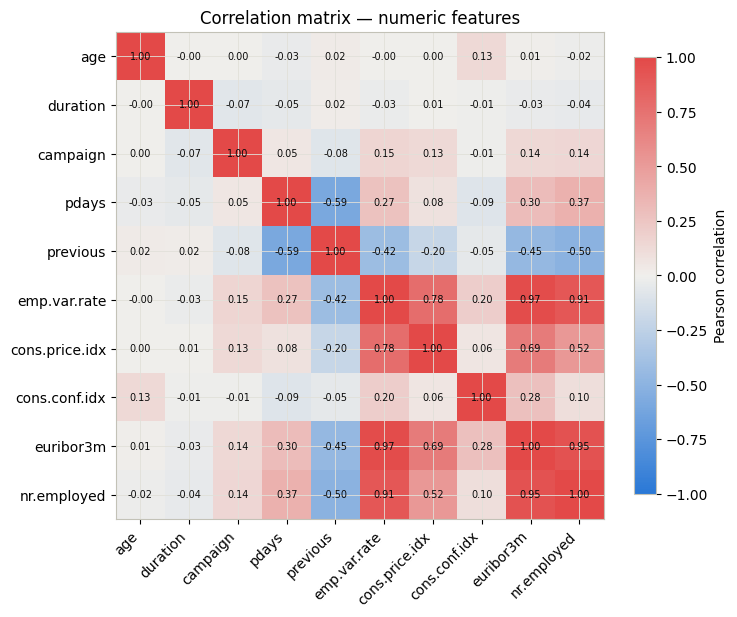

In [35]:
diverging_cmap = LinearSegmentedColormap.from_list('diverging', [BLUE, '#f0efec', RED])
corr = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(numerical_cols)))
ax.set_yticks(range(len(numerical_cols)))
ax.set_xticklabels(numerical_cols, rotation=45, ha='right')
ax.set_yticklabels(numerical_cols)
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7, color='#0b0b0b')
fig.colorbar(im, ax=ax, label='Pearson correlation', shrink=0.8)
ax.set_title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

The five economic/employment indicators are strongly inter-correlated: `emp.var.rate`, `euribor3m`, and `nr.employed` all pairwise correlate at 0.91–0.97, and `cons.price.idx` correlates 0.69–0.78 with each of them. This is expected — they're macroeconomic indicators that move together — but it's substantial multicollinearity that later notebooks (especially linear baselines) will need to account for. `pdays` and `previous` correlate at -0.59, consistent with the Section 8 finding that they encode overlapping prior-contact information.

## Key EDA Findings

### Target / Business Findings
- Overall subscription rate is 11.27% (4,640 of 41,176 clients) — the class imbalance flagged in notebook 01 is confirmed and should drive metric choice (precision/recall/PR-AUC over accuracy) in later modeling.

### Customer Characteristics
- `job`: highest rates among `student` (31.4%) and `retired` (25.3%); lowest among `blue-collar` (6.9%) and `services` (8.1%).
- `education`: no clean monotonic pattern; `university.degree` (13.7%) highest among reliably-sized categories, `basic.9y` (7.8%) lowest.
- `marital`: `single` (14.0%) higher than `married` (10.2%) or `divorced` (10.3%).
- `housing` and `loan` show almost no association with subscription on their own (both stay within roughly 10.8–11.6%).
- `default`'s `unknown` category behaves very differently from its `no` category (5.2% vs 12.9%) — the clearest evidence in the dataset that `'unknown'` can carry real signal, and that its treatment shouldn't be assumed uniform across columns. `job` and `marital`'s `unknown` categories, by contrast, sit close to their column's overall rate.

### Campaign / Contact Findings
- `contact == 'cellular'` (14.7%) far exceeds `telephone` (5.2%).
- `month` shows the widest swing of any categorical feature (6.4%–50.6%), but high-rate months have much smaller sample sizes and may be entangled with time-varying economic conditions rather than a pure calendar effect.
- `day_of_week` is not meaningfully associated with subscription (9.95%–12.11% range).
- More contacts within a campaign associates with a *lower* subscription rate: 13.0% (1 contact) down to 4.6% (7+ contacts).

### Previous Campaign Findings
- `poutcome == 'success'` shows the strongest single-feature association found: 65.1% vs 14.2% (`failure`) and 8.8% (`nonexistent`).
- Subscription rate rises with prior contact count: 8.8% (0 prior contacts) → 21.2% (1) → 43.9% (2+).
- `pdays != 999` (i.e., a recorded prior-contact date) associates with a 63.8% rate, versus 9.3% for the `999` sentinel.

### Data Quality Observations
- `pdays == 999` does not perfectly mean *"never contacted before"*: 4,110 clients with `previous > 0` and `poutcome == 'failure'` still carry `pdays == 999`. All `poutcome == 'success'` clients have a real `pdays` value; 97% of `poutcome == 'failure'` clients do not. This is a data-structure nuance rather than an error, but it directly affects how a "previously contacted" flag should be engineered.

### Questions to Carry Forward
- Notebook 03: `duration` shows by far the strongest individual correlation with the target (+0.41) and a clear median gap between subscribers and non-subscribers (449s vs 180s) — exactly the pattern that motivates a dedicated leakage investigation against the defined prediction scenario.
- Notebook 03/04: `month`'s strong association with the target should be examined alongside `duration` and the economic indicators, since this dataset spans 2008–2010 and month may be a proxy for *when* in that window a contact happened rather than an independent seasonal effect.
- Notebook 04: a "previously contacted" flag should not be built as a naive `pdays != 999` check — `pdays`, `previous`, and `poutcome` disagree on roughly 4,110 clients (~10% of the previously-contacted population), and the correct definition needs to be decided deliberately.
- Notebook 04: `default`'s `unknown` category carries real signal (5.2% vs 12.9%) while `job`'s and `housing`/`loan`'s do not — a single uniform encoding rule for `'unknown'` across all six affected columns may not be the best choice; worth deciding per-column.
- Notebook 04/06: the strong multicollinearity among `emp.var.rate`, `euribor3m`, `nr.employed`, and `cons.price.idx` (pairwise correlations 0.69–0.97) should inform feature selection, especially for linear baselines.